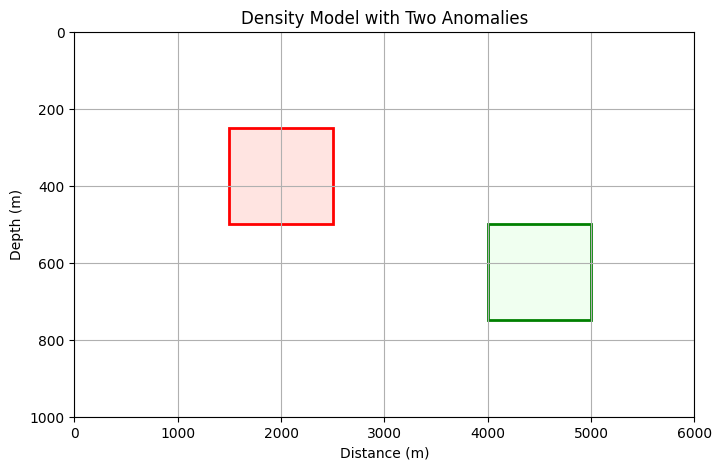

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

dx = 10
x_profile = np.arange(0, 6000, dx)

# Negative Anomaly
b1_x1, b1_x2 = 1500, 2500
b1_z1, b1_z2 = 250, 500
b1_drho = -570

# Positive Anomaly
b2_x1, b2_x2 = 4000, 5000
b2_z1, b2_z2 = 500, 750
b2_drho = 430

plt.figure(figsize=(8,5))
ax = plt.gca()

rect1 = patches.Rectangle((b1_x1, b1_z1), b1_x2 - b1_x1, b1_z2 - b1_z1, linewidth=2, edgecolor='red', facecolor='mistyrose', label='2.1 g/cc')
rect2 = patches.Rectangle((b2_x1, b2_z1), b2_x2 - b2_x1, b2_z2 - b2_z1, linewidth=2, edgecolor='green', facecolor='honeydew',  label='31 g/cc')

ax.add_patch(rect1)
ax.add_patch(rect2)

ax.set_xlim(0,6000)
ax.set_ylim(1000,0)
ax.set_title("Density Model with Two Anomalies")
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Depth (m)")
ax.grid(True)
plt.show()


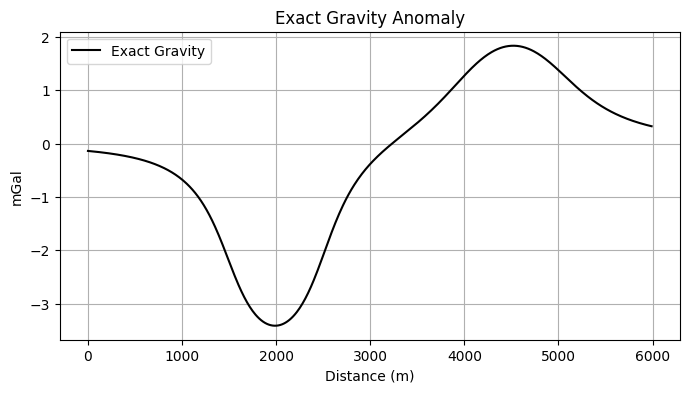

In [23]:
#Talwani Method to find the Gravity anomaly
def calc_2d_prism_gravity(x, x1, x2, z1, z2, delta_rho):
    G = 6.67430e-11
    
    def gravity_term(x_diff, z):
        z = max(z, 1e-9)
        r = np.sqrt(x_diff**2 + z**2)
        theta = np.arctan2(x_diff, z)
        return x_diff * np.log(r) + z * theta

    t11 = gravity_term(x - x1, z1)
    t12 = gravity_term(x - x1, z2)
    t21 = gravity_term(x - x2, z1)
    t22 = gravity_term(x - x2, z2)

    gz = 2 * G * delta_rho * (t12 - t11 - t22 + t21)
    return gz * 1e5

g_b1 = calc_2d_prism_gravity(x_profile, b1_x1, b1_x2, b1_z1, b1_z2, b1_drho)
g_b2 = calc_2d_prism_gravity(x_profile, b2_x1, b2_x2, b2_z1, b2_z2, b2_drho)
g_total_exact = g_b1 + g_b2

plt.figure(figsize=(8,4))
plt.plot(x_profile, g_total_exact, 'k-', label='Exact Gravity')
plt.title("Exact Gravity Anomaly")
plt.xlabel("Distance (m)")
plt.ylabel("mGal")
plt.legend()
plt.grid(True)
plt.show()

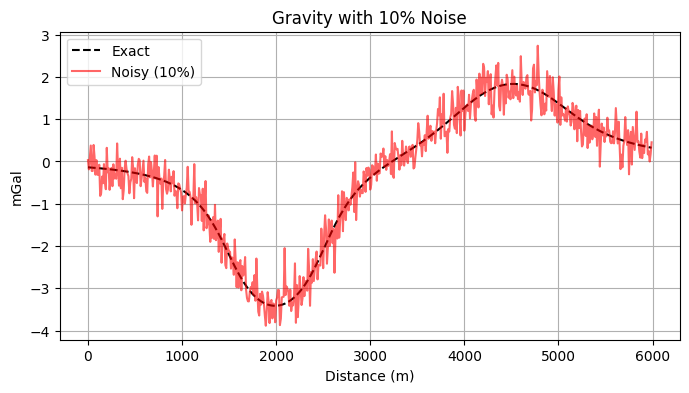

In [15]:
#Adding 10% noise to the gravity anomaly plot 
np.random.seed(36)
noise_level = 0.10 * np.max(np.abs(g_total_exact))
noise = np.random.normal(0, noise_level, len(x_profile))
g_noisy = g_total_exact + noise

plt.figure(figsize=(8,4))
plt.plot(x_profile, g_total_exact, 'k--', label='Exact')
plt.plot(x_profile, g_noisy, 'r-', alpha=0.6, label='Noisy Data')
plt.title("Gravity with 10% Noise")
plt.xlabel("Distance (m)")
plt.ylabel("mGal")
plt.legend()
plt.grid(True)
plt.show()

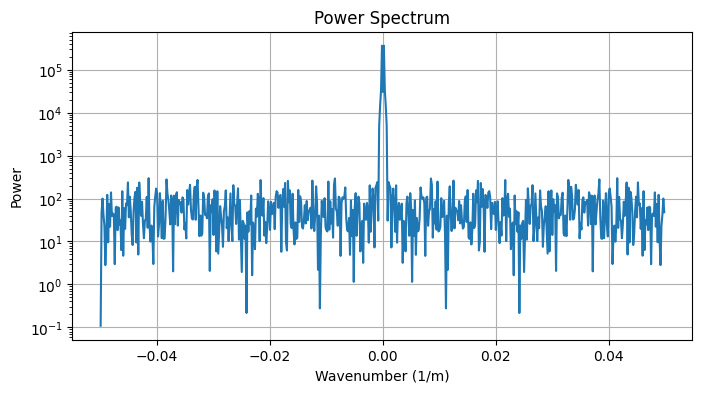

In [16]:
#Applying FFT
N = len(x_profile)
G_k = np.fft.fft(g_noisy)
k = np.fft.fftfreq(N, d=dx)
power_spectrum = np.abs(G_k)**2

plt.figure(figsize=(8,4))
plt.semilogy(np.fft.fftshift(k), np.fft.fftshift(power_spectrum))
plt.title("Power Spectrum")
plt.xlabel("Wavenumber (1/m)")
plt.ylabel("Power")
plt.grid(True)
plt.show()

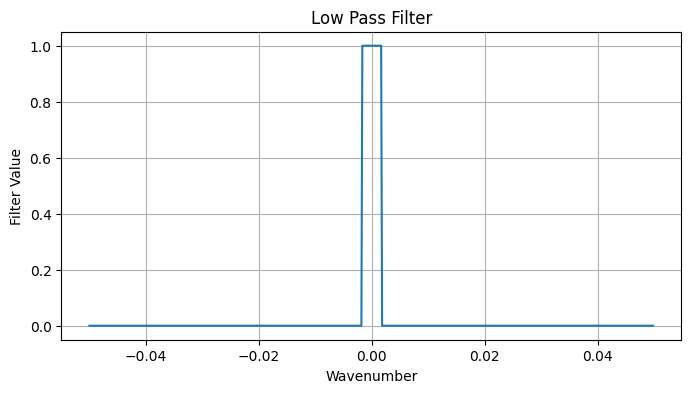

In [17]:
#Filtering
cutoff_wavenumber = 1 / 600.0

low_pass_filter = np.zeros(N)
low_pass_filter[np.abs(k) < cutoff_wavenumber] = 1

G_k_filtered = G_k * low_pass_filter

plt.figure(figsize=(8,4))
plt.plot(np.fft.fftshift(k), np.fft.fftshift(low_pass_filter))
plt.title("Low Pass Filter")
plt.xlabel("Wavenumber")
plt.ylabel("Filter Value")
plt.grid(True)
plt.show()

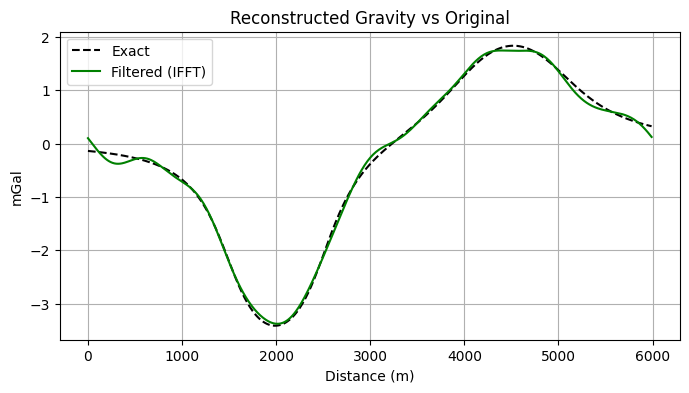

Reconstruction Accuracy: 99.81%


In [31]:
#Applying Inverse FFT
g_reconstructed = np.fft.ifft(G_k_filtered).real

plt.figure(figsize=(8,4))
plt.plot(x_profile, g_total_exact, 'k--', label='Exact')
plt.plot(x_profile, g_reconstructed, 'g-', label='Filtered (IFFT)')
plt.title("Reconstructed Gravity vs Original")
plt.xlabel("Distance (m)")
plt.ylabel("mGal")
plt.legend()
plt.grid(True)
plt.show()
mse = np.mean((g_pred - g_total_exact)**2)
variance = np.var(g_total_exact)

accuracy = (1 - mse / variance) * 100

print(f"Reconstruction Accuracy: {accuracy:.2f}%")

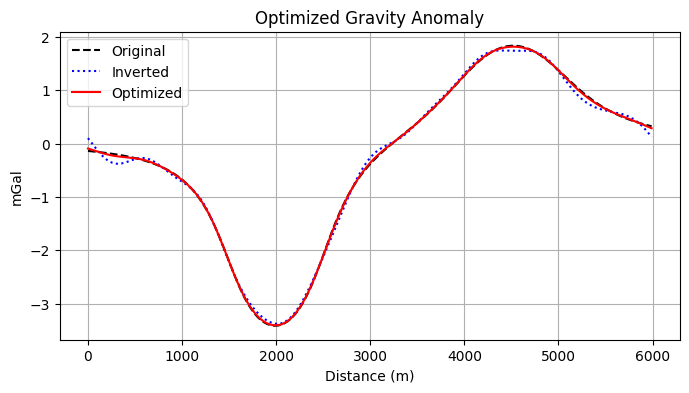

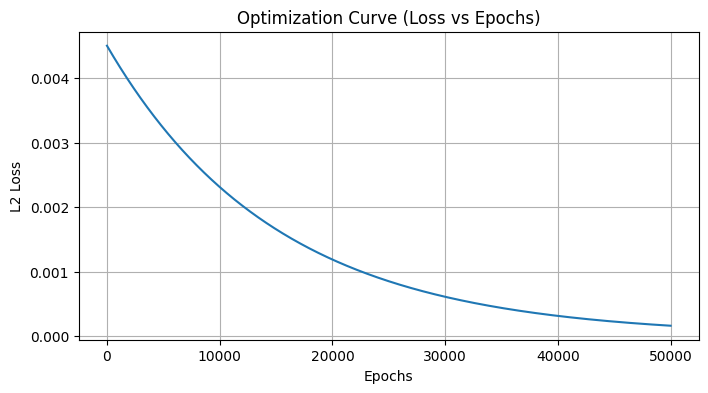

Reconstruction Accuracy: 99.99%


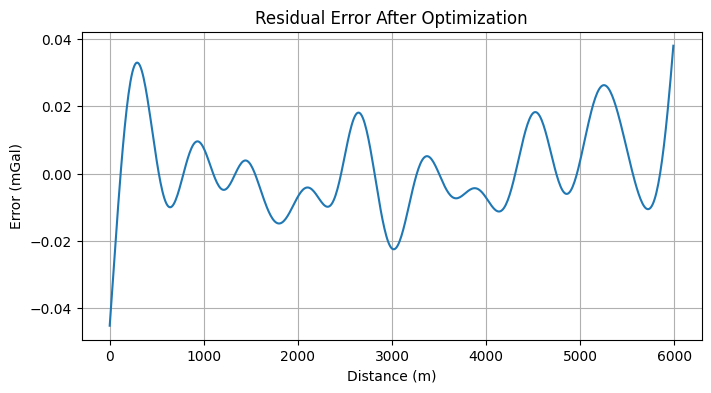

In [34]:
#Optimization of the Inverted Gravity anomaly plot
g_pred = g_reconstructed.copy()

lr = 0.01
epochs = 50000
loss_history = []

#Gradient Descent (using L2 norm)
for epoch in range(epochs):
    loss = np.mean((g_pred - g_total_exact)**2)
    loss_history.append(loss)
    grad = 2 * (g_pred - g_total_exact) / len(g_pred)
    g_pred = g_pred - lr * grad


#Optimized vs Original
plt.figure(figsize=(8,4))
plt.plot(x_profile, g_total_exact, 'k--', label='Original')
plt.plot(x_profile, g_reconstructed, 'b:', label='Inverted')
plt.plot(x_profile, g_pred, 'r-', label='Optimized')
plt.title("Optimized Gravity Anomaly")
plt.xlabel("Distance (m)")
plt.ylabel("mGal")
plt.legend()
plt.grid(True)
plt.show()


#Loss Curve
plt.figure(figsize=(8,4))
plt.plot(range(epochs), loss_history)
plt.title("Optimization Curve (Loss vs Epochs)")
plt.xlabel("Epochs")
plt.ylabel("L2 Loss")
plt.grid(True)
plt.show()

#Accuracy
mse = np.mean((g_pred - g_total_exact)**2)
variance = np.var(g_total_exact)

accuracy = (1 - mse / variance) * 100

print(f"Reconstruction Accuracy: {accuracy:.2f}%")

#Error Plot
error = g_total_exact - g_pred

plt.figure(figsize=(8,4))
plt.plot(x_profile, error)
plt.title("Residual Error After Optimization")
plt.xlabel("Distance (m)")
plt.ylabel("Error (mGal)")
plt.grid(True)
plt.show()